# Telecom X — Parte 2: Modelo Predictivo de Evasión de Clientes (Churn)

> **Objetivo:** Construir, evaluar y comparar modelos de Machine Learning para predecir qué clientes tienen mayor probabilidad de cancelar el servicio, identificar las variables más influyentes y generar recomendaciones estratégicas basadas en los resultados.

---

### Pipeline de la Parte 2
| Etapa | Descripción |
|-------|-------------|
| **1. Carga y Preparación** | Importar dataset limpio, encoding, normalización |
| **2. Análisis de Clases** | Verificar desbalance, aplicar SMOTE si es necesario |
| **3. Correlación y Selección** | Análisis de correlación dirigida y selección de features |
| **4. Modelado** | Logistic Regression, Random Forest, XGBoost |
| **5. Evaluación** | Accuracy, Precision, Recall, F1, AUC-ROC |
| **6. Importancia de Variables** | Feature importance de los modelos |
| **7. Conclusión Estratégica** | Perfil de riesgo y recomendaciones |

---
**Dataset fuente:** `TelecomX_clean.csv` generado en la Parte 1  
**Registros:** 7,043 clientes · **Churn global:** ~26.5%

## 0. Instalación e Importación de Librerías

In [1]:
# ── Instalación de librerías adicionales (ejecutar en Google Colab) ──
# !pip install imbalanced-learn xgboost --quiet

# ── Librerías estándar ──
import json
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Scikit-learn ──
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score,
    accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.utils import resample

# ── Imbalanced-learn (SMOTE) ──
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print(' imbalanced-learn no disponible — se usará oversampling manual')

# ── XGBoost ──
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print(' XGBoost no disponible — se usará GradientBoostingClassifier como alternativa')

# ── Configuración visual ──
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
COLORS = {'churn': '#e74c3c', 'no_churn': '#2ecc71', 'neutral': '#3498db', 'warn': '#e67e22'}

print(' Librerías cargadas correctamente')

 Librerías cargadas correctamente


---
## 1. Carga y Preparación de Datos

Cargamos el dataset limpio generado en la Parte 1. Si no está disponible localmente, lo reconstruimos desde la API original aplicando el mismo pipeline ETL.

In [2]:
# ── 1.1 Carga del dataset limpio desde la Parte 1 ──
# Opción A: desde archivo CSV local / Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/TelecomX_clean.csv')

# Opción B: reconstrucción desde la API (pipeline ETL completo)
URL_API = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

response = requests.get(URL_API)
response.raise_for_status()
raw_data = response.json()
df_raw = pd.json_normalize(raw_data)

# Renombrado
rename_map = {
    'customerID': 'customer_id', 'Churn': 'churn',
    'customer.gender': 'gender', 'customer.SeniorCitizen': 'senior_citizen',
    'customer.Partner': 'partner', 'customer.Dependents': 'dependents',
    'customer.tenure': 'tenure',
    'phone.PhoneService': 'phone_service', 'phone.MultipleLines': 'multiple_lines',
    'internet.InternetService': 'internet_service',
    'internet.OnlineSecurity': 'online_security',
    'internet.OnlineBackup': 'online_backup',
    'internet.DeviceProtection': 'device_protection',
    'internet.TechSupport': 'tech_support',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_movies',
    'account.Contract': 'contract',
    'account.PaperlessBilling': 'paperless_billing',
    'account.PaymentMethod': 'payment_method',
    'account.Charges.Monthly': 'monthly_charges',
    'account.Charges.Total': 'total_charges',
}
df = df_raw.rename(columns=rename_map).copy()

# Limpieza
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df['churn'] = df['churn'].replace('', np.nan)
df_clean = df.dropna(subset=['churn']).copy()
df_clean['total_charges'].fillna(df_clean['total_charges'].median(), inplace=True)

# Estandarización binaria
binary_cols = ['partner', 'dependents', 'phone_service', 'paperless_billing',
               'online_security', 'online_backup', 'device_protection',
               'tech_support', 'streaming_tv', 'streaming_movies']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0,
                                        'No internet service': 0, 'No phone service': 0})

df_clean['churn']          = df_clean['churn'].map({'Yes': 1, 'No': 0}).astype(int)
df_clean['gender']         = df_clean['gender'].map({'Male': 1, 'Female': 0})
df_clean['multiple_lines'] = df_clean['multiple_lines'].map({'Yes': 1, 'No': 0, 'No phone service': 0})

# Feature engineering
service_cols = ['phone_service', 'multiple_lines', 'online_security',
                'online_backup', 'device_protection', 'tech_support',
                'streaming_tv', 'streaming_movies']
df_clean['total_services']    = df_clean[service_cols].sum(axis=1)
df_clean['charge_per_service'] = (df_clean['monthly_charges'] / df_clean['total_services'].replace(0, 1)).round(2)
df_clean['tenure_group']      = pd.cut(df_clean['tenure'], bins=[0,12,24,48,72],
                                        labels=['0-12m','13-24m','25-48m','49-72m'], include_lowest=True)

print(f' Dataset cargado y reconstruido correctamente')
print(f'   Shape: {df_clean.shape}')
print(f'   Tasa de churn: {df_clean["churn"].mean()*100:.1f}%')
df_clean.head(3)

 Dataset cargado y reconstruido correctamente
   Shape: (7043, 24)
   Tasa de churn: 26.5%


,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,total_services,charge_per_service,tenure_group
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,1,0,One year,1,Mailed check,65.6,593.30,4,16.40,0-12m
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,1,Month-to-month,0,Mailed check,59.9,542.40,3,19.97,0-12m
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,0,0,Month-to-month,1,Electronic check,73.9,280.85,2,36.95,0-12m


### 1.2 Preparación Adicional para Modelado
Eliminamos columnas no útiles para el modelo y aplicamos **One-Hot Encoding** a las variables categóricas nominales.

In [3]:
# ── 1.2 Encoding de variables categóricas nominales ──

# Columnas a eliminar: ID no predictivo y columnas derivadas con alta multicolinealidad
cols_drop = ['customer_id', 'tenure_group']  # tenure_group ya está capturada por tenure numérico
df_model = df_clean.drop(columns=cols_drop).copy()

# One-Hot Encoding para variables con más de 2 categorías
cat_cols = ['internet_service', 'contract', 'payment_method']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=False, dtype=int)

print(f'Shape después del encoding: {df_model.shape}')
print(f'\nColumnas del dataset de modelado:')
for i, col in enumerate(df_model.columns, 1):
    print(f'  {i:2d}. {col}')

Shape después del encoding: (7043, 29)

Columnas del dataset de modelado:
   1. churn
   2. gender
   3. senior_citizen
   4. partner
   5. dependents
   6. tenure
   7. phone_service
   8. multiple_lines
   9. online_security
  10. online_backup
  11. device_protection
  12. tech_support
  13. streaming_tv
  14. streaming_movies
  15. paperless_billing
  16. monthly_charges
  17. total_charges
  18. total_services
  19. charge_per_service
  20. internet_service_DSL
  21. internet_service_Fiber optic
  22. internet_service_No
  23. contract_Month-to-month
  24. contract_One year
  25. contract_Two year
  26. payment_method_Bank transfer (automatic)
  27. payment_method_Credit card (automatic)
  28. payment_method_Electronic check
  29. payment_method_Mailed check


---
## 2. Análisis de Balance de Clases

Verificamos si existe desbalance entre clientes que cancelaron (churn=1) y los que no, y evaluamos si es necesario aplicar técnicas de balanceo.

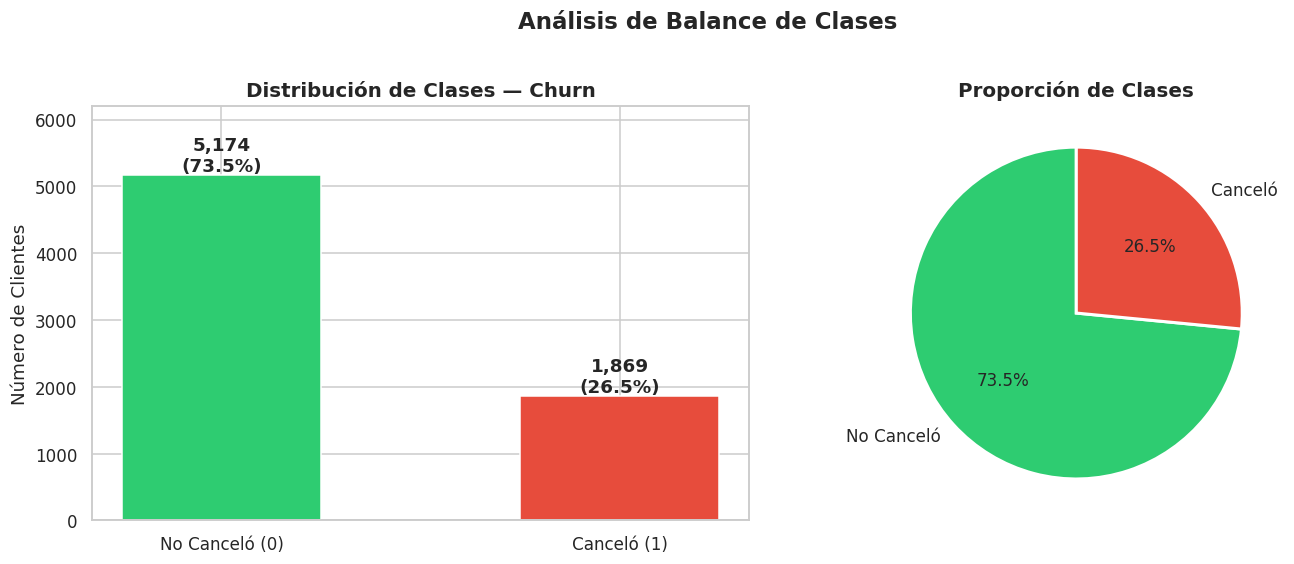

Ratio de desbalance (0:1) → 2.77:1
 Desbalance moderado — se usará class_weight="balanced" en los modelos


In [4]:
# ── 2.1 Distribución de clases ──
churn_counts = df_model['churn'].value_counts()
churn_pct    = df_model['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
bars = axes[0].bar(['No Canceló (0)', 'Canceló (1)'],
                   churn_counts.values,
                   color=[COLORS['no_churn'], COLORS['churn']],
                   edgecolor='white', width=0.5)
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribución de Clases — Churn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Clientes')
axes[0].set_ylim(0, churn_counts.max() * 1.2)

# Pie
axes[1].pie(churn_counts.values,
            labels=['No Canceló', 'Canceló'],
            colors=[COLORS['no_churn'], COLORS['churn']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.suptitle('Análisis de Balance de Clases', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ratio = churn_counts[0] / churn_counts[1]
print(f'Ratio de desbalance (0:1) → {ratio:.2f}:1')
if ratio > 3:
    print(' Desbalance significativo — se aplicará balanceo en el entrenamiento')
else:
    print(' Desbalance moderado — se usará class_weight="balanced" en los modelos')

In [5]:
# ── 2.2 Estrategia de balanceo ──
# Dado el desbalance ~73.5% / 26.5%, usamos dos estrategias:
# a) class_weight='balanced' en modelos que lo soporten
# b) Oversampling manual (si SMOTE no está disponible)

# Separar features y target
X = df_model.drop(columns=['churn'])
y = df_model['churn']

# División estratificada train / test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} registros | Test: {X_test.shape[0]:,} registros')
print(f'Churn en train: {y_train.mean()*100:.1f}% | Churn en test: {y_test.mean()*100:.1f}%')

# Balanceo por oversampling en train
if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
    print(f'\n SMOTE aplicado — Train balanceado: {X_train_bal.shape[0]:,} registros')
else:
    # Oversampling manual
    train_df = pd.concat([X_train, y_train], axis=1)
    majority  = train_df[train_df['churn'] == 0]
    minority  = train_df[train_df['churn'] == 1]
    minority_up = resample(minority, replace=True, n_samples=len(majority), random_state=42)
    train_bal = pd.concat([majority, minority_up])
    X_train_bal = train_bal.drop(columns=['churn'])
    y_train_bal = train_bal['churn']
    print(f'\n Oversampling manual aplicado — Train balanceado: {X_train_bal.shape[0]:,} registros')

print(f'Distribución balanceada: {y_train_bal.value_counts().to_dict()}')

Train: 5,634 registros | Test: 1,409 registros
Churn en train: 26.5% | Churn en test: 26.5%

 SMOTE aplicado — Train balanceado: 8,278 registros
Distribución balanceada: {0: 4139, 1: 4139}


---
## 3. Correlación y Selección de Variables

Realizamos un análisis dirigido de la relación entre cada variable y el churn, usando múltiples métricas para seleccionar las features más relevantes para el modelado.

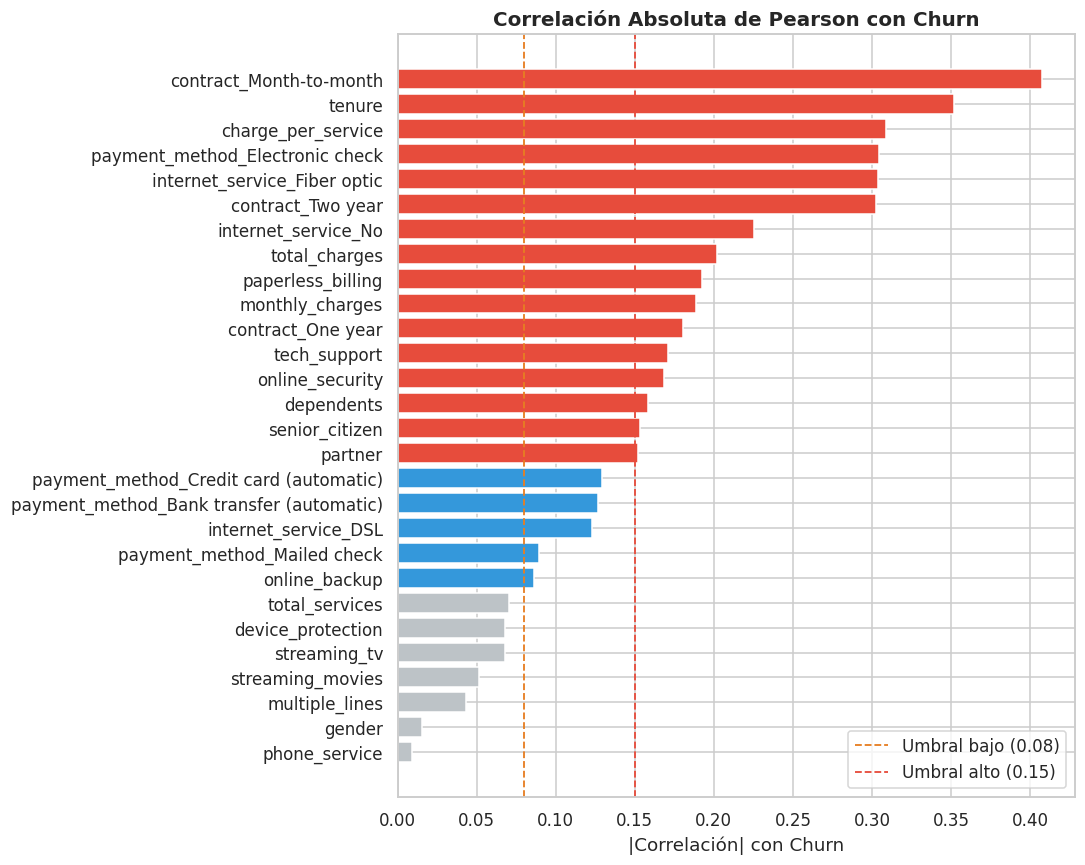

Top 10 variables más correlacionadas con Churn:
contract_Month-to-month            0.408
tenure                             0.352
charge_per_service                 0.309
payment_method_Electronic check    0.304
internet_service_Fiber optic       0.304
contract_Two year                  0.303
internet_service_No                0.226
total_charges                      0.202
paperless_billing                  0.193
monthly_charges                    0.189


In [6]:
# ── 3.1 Correlación de Pearson con Churn ──
corr_churn = X_train.corrwith(y_train).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = [COLORS['churn'] if v > 0.15 else COLORS['neutral'] if v > 0.08 else '#bdc3c7'
              for v in corr_churn.values]
bars = ax.barh(corr_churn.index[::-1], corr_churn.values[::-1],
               color=colors_bar[::-1], edgecolor='white')
ax.axvline(0.08, color=COLORS['warn'], linestyle='--', linewidth=1.2, label='Umbral bajo (0.08)')
ax.axvline(0.15, color=COLORS['churn'], linestyle='--', linewidth=1.2, label='Umbral alto (0.15)')
ax.set_title('Correlación Absoluta de Pearson con Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('|Correlación| con Churn')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 10 variables más correlacionadas con Churn:')
print(corr_churn.head(10).round(3).to_string())

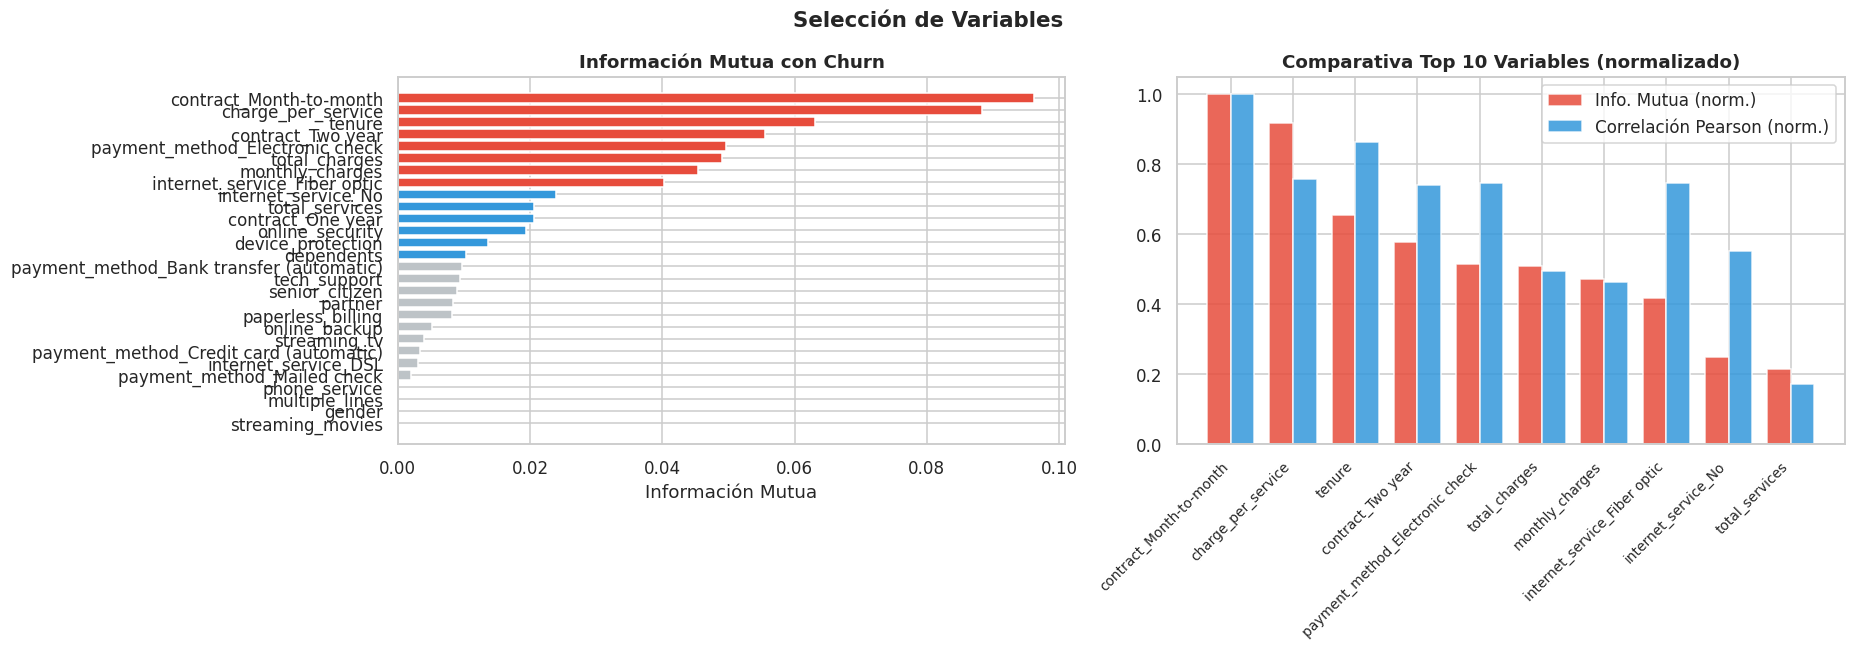


Variables seleccionadas (MI > 0.005): 20
['contract_Month-to-month', 'charge_per_service', 'tenure', 'contract_Two year', 'payment_method_Electronic check', 'total_charges', 'monthly_charges', 'internet_service_Fiber optic', 'internet_service_No', 'total_services', 'contract_One year', 'online_security', 'device_protection', 'dependents', 'payment_method_Bank transfer (automatic)', 'tech_support', 'senior_citizen', 'partner', 'paperless_billing', 'online_backup']


In [7]:
# ── 3.2 Información Mutua (captura relaciones no lineales) ──
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Información mutua
colors_mi = [COLORS['churn'] if v > 0.03 else COLORS['neutral'] if v > 0.01 else '#bdc3c7'
             for v in mi_series.values]
axes[0].barh(mi_series.index[::-1], mi_series.values[::-1],
             color=colors_mi[::-1], edgecolor='white')
axes[0].set_title('Información Mutua con Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Información Mutua')

# Comparativa top 10
top10 = mi_series.head(10)
x_pos = np.arange(len(top10))
corr_top10 = corr_churn[top10.index]
w = 0.38
axes[1].bar(x_pos - w/2, top10.values / top10.max(), width=w,
            color=COLORS['churn'], label='Info. Mutua (norm.)', alpha=0.85)
axes[1].bar(x_pos + w/2, corr_top10.values / corr_top10.max(), width=w,
            color=COLORS['neutral'], label='Correlación Pearson (norm.)', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(top10.index, rotation=45, ha='right', fontsize=9)
axes[1].set_title('Comparativa Top 10 Variables (normalizado)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Selección de Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Variables seleccionadas
selected_features = mi_series[mi_series > 0.005].index.tolist()
print(f'\nVariables seleccionadas (MI > 0.005): {len(selected_features)}')
print(selected_features)

In [8]:
# ── 3.3 Normalización / Estandarización ──
# Aplicamos StandardScaler a variables numéricas continuas

scaler = StandardScaler()
num_cols_scale = ['tenure', 'monthly_charges', 'total_charges',
                  'total_services', 'charge_per_service']

# Aplicar solo en las columnas que existen
num_cols_scale = [c for c in num_cols_scale if c in X_train.columns]

X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_bal_sc = X_train_bal.copy()

X_train_sc[num_cols_scale]     = scaler.fit_transform(X_train[num_cols_scale])
X_test_sc[num_cols_scale]      = scaler.transform(X_test[num_cols_scale])
X_train_bal_sc[num_cols_scale] = scaler.transform(X_train_bal[num_cols_scale])

print(f' Estandarización aplicada a: {num_cols_scale}')
print(f'   Media post-scaler (train): {X_train_sc[num_cols_scale].mean().round(3).to_dict()}')

 Estandarización aplicada a: ['tenure', 'monthly_charges', 'total_charges', 'total_services', 'charge_per_service']
   Media post-scaler (train): {'tenure': -0.0, 'monthly_charges': 0.0, 'total_charges': 0.0, 'total_services': -0.0, 'charge_per_service': -0.0}


---
## 4. Construcción de Modelos Predictivos

Entrenamos y comparamos tres modelos con diferentes paradigmas:
- **Logistic Regression:** Modelo lineal interpretable, ideal como baseline
- **Random Forest:** Ensemble de árboles, captura relaciones no lineales
- **Gradient Boosting / XGBoost:** Boosting secuencial, alto performance

In [9]:
# ── 4.1 Definición de modelos ──

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
}

if XGB_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42, eval_metric='logloss', verbosity=0
    )
else:
    models['Gradient Boosting'] = GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
    )

print(' Modelos a entrenar:')
for name in models:
    print(f'   • {name}')

 Modelos a entrenar:
   • Logistic Regression
   • Random Forest
   • XGBoost


In [10]:
# ── 4.2 Entrenamiento y evaluación de todos los modelos ──

results = {}

for name, model in models.items():
    print(f'\n Entrenando: {name}...')

    # Elegir conjunto de entrenamiento
    if name == 'Logistic Regression':
        Xtr, ytr = X_train_sc, y_train   # LR ya usa class_weight
        Xte = X_test_sc
    elif name in ['Random Forest']:
        Xtr, ytr = X_train_bal, y_train_bal  # RF con train balanceado
        Xte = X_test
    else:
        Xtr, ytr = X_train_bal, y_train_bal
        Xte = X_test

    model.fit(Xtr, ytr)
    y_pred      = model.predict(Xte)
    y_pred_proba = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'model'       : model,
        'y_pred'      : y_pred,
        'y_proba'     : y_pred_proba,
        'accuracy'    : accuracy_score(y_test, y_pred),
        'precision'   : precision_score(y_test, y_pred),
        'recall'      : recall_score(y_test, y_pred),
        'f1'          : f1_score(y_test, y_pred),
        'roc_auc'     : roc_auc_score(y_test, y_pred_proba),
    }
    print(f'   Accuracy: {results[name]["accuracy"]*100:.1f}% | '
          f'F1: {results[name]["f1"]*100:.1f}% | '
          f'AUC-ROC: {results[name]["roc_auc"]:.3f}')

print('\n Todos los modelos entrenados')


 Entrenando: Logistic Regression...
   Accuracy: 74.0% | F1: 61.5% | AUC-ROC: 0.844

 Entrenando: Random Forest...
   Accuracy: 77.1% | F1: 61.1% | AUC-ROC: 0.835

 Entrenando: XGBoost...
   Accuracy: 73.9% | F1: 61.9% | AUC-ROC: 0.831

 Todos los modelos entrenados


---
## 5. Evaluación de Modelos

Comparamos los modelos usando métricas clave de clasificación binaria, matrices de confusión y curvas ROC.

In [11]:
# ── 5.1 Tabla comparativa de métricas ──
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  f"{res['accuracy']*100:.2f}%",
        'Precision': f"{res['precision']*100:.2f}%",
        'Recall':    f"{res['recall']*100:.2f}%",
        'F1-Score':  f"{res['f1']*100:.2f}%",
        'AUC-ROC':   f"{res['roc_auc']:.4f}",
    }
    for name, res in results.items()
}).T

print('=' * 65)
print('           COMPARATIVA DE MÉTRICAS POR MODELO')
print('=' * 65)
print(metrics_df.to_string())
print('=' * 65)

           COMPARATIVA DE MÉTRICAS POR MODELO
                    Accuracy Precision  Recall F1-Score AUC-ROC
Logistic Regression   73.95%    50.60%  78.34%   61.49%  0.8436
Random Forest         77.15%    55.73%  67.65%   61.11%  0.8352
XGBoost               73.88%    50.51%  79.95%   61.90%  0.8314


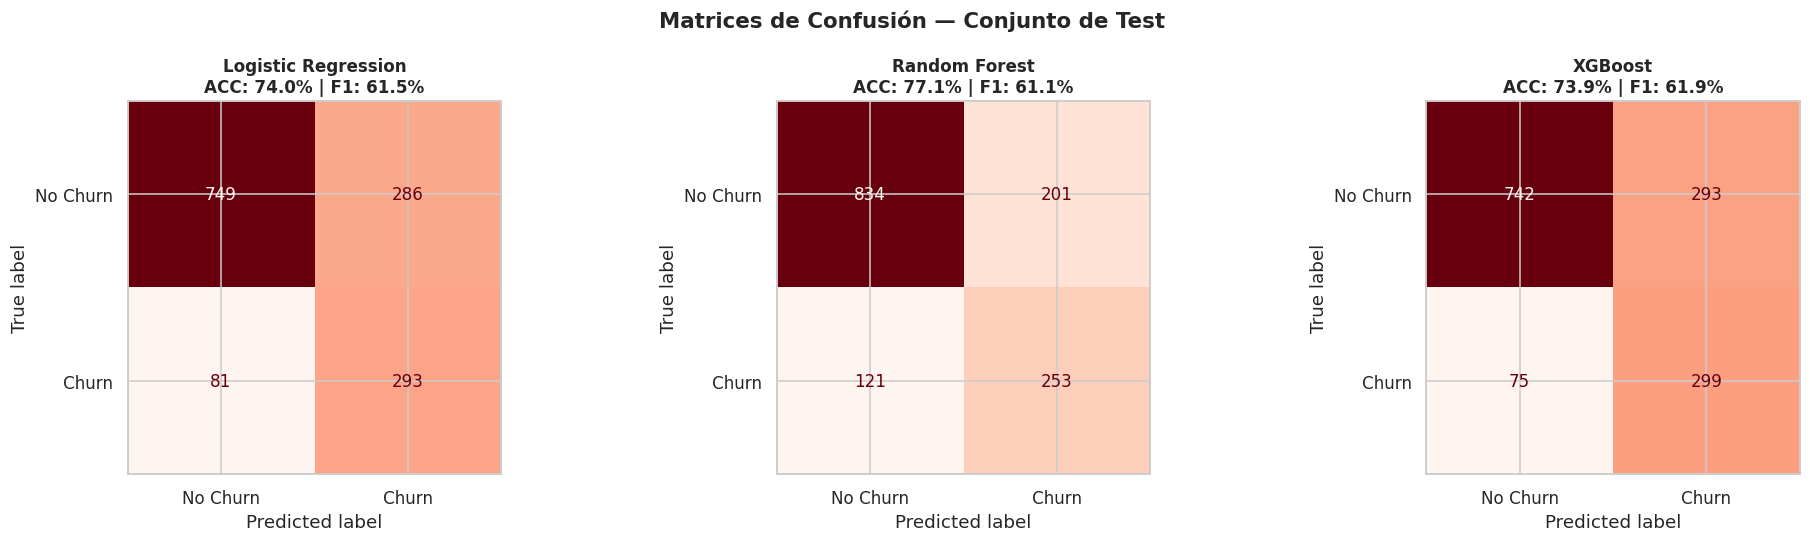

In [12]:
# ── 5.2 Matrices de Confusión ──
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap='Reds', colorbar=False)
    ax.set_title(f'{name}\nACC: {res["accuracy"]*100:.1f}% | F1: {res["f1"]*100:.1f}%',
                 fontsize=11, fontweight='bold')

plt.suptitle('Matrices de Confusión — Conjunto de Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

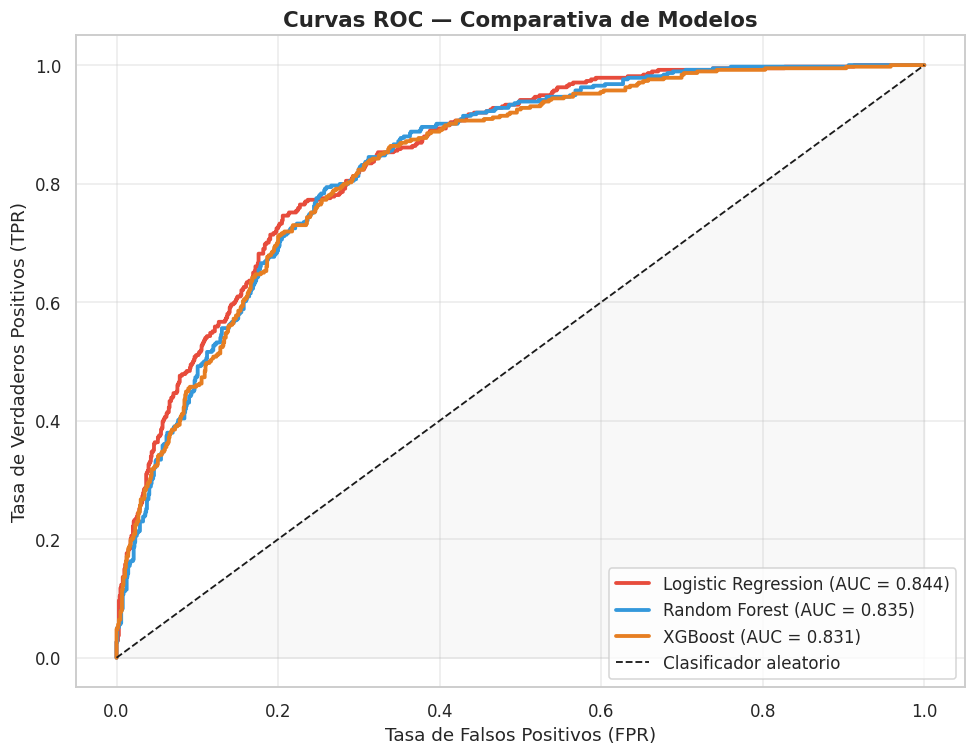

In [13]:
# ── 5.3 Curvas ROC ──
fig, ax = plt.subplots(figsize=(9, 7))
palette = [COLORS['churn'], COLORS['neutral'], COLORS['warn'], '#9b59b6']

for (name, res), color in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f"{name} (AUC = {res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparativa de Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

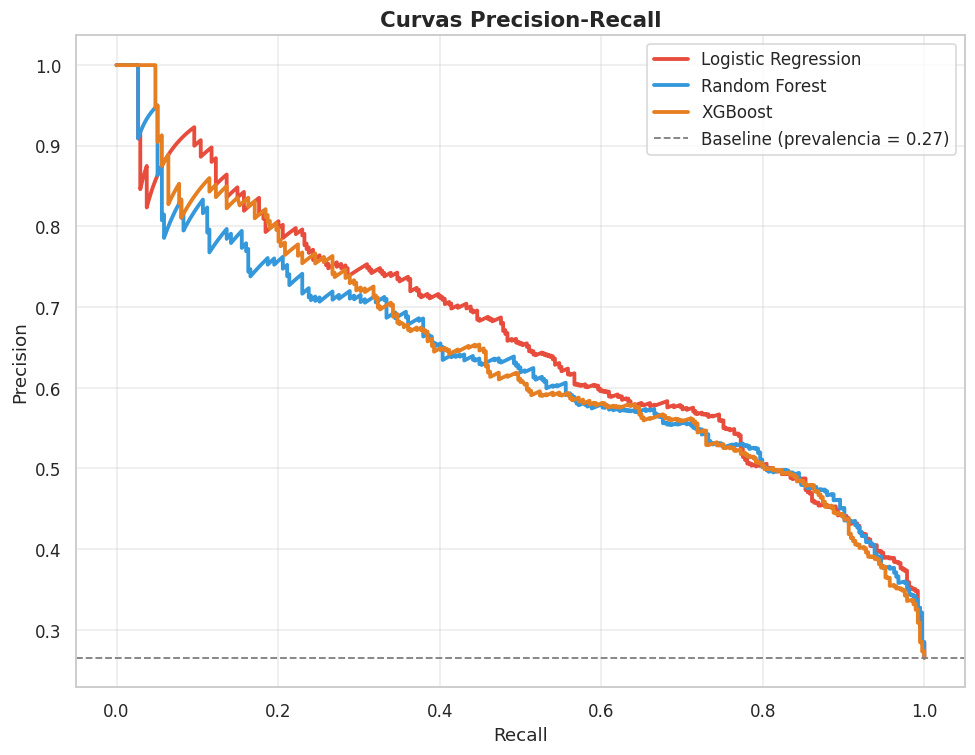

In [14]:
# ── 5.4 Curvas Precision-Recall ──
fig, ax = plt.subplots(figsize=(9, 7))

for (name, res), color in zip(results.items(), palette):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ax.plot(rec, prec, lw=2.5, color=color, label=name)

baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', lw=1.2,
           label=f'Baseline (prevalencia = {baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curvas Precision-Recall', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [15]:
# ── 5.5 Reporte detallado del mejor modelo ──
best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
best_res = results[best_model_name]

print(f'🏆 Mejor modelo por AUC-ROC: {best_model_name}')
print(f'   AUC-ROC: {best_res["roc_auc"]:.4f}\n')
print('Classification Report:')
print(classification_report(y_test, best_res['y_pred'],
                             target_names=['No Churn', 'Churn']))

🏆 Mejor modelo por AUC-ROC: Logistic Regression
   AUC-ROC: 0.8436

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



---
## 6. Análisis de Importancia de Variables

Identificamos cuáles son los factores que más influyen en la predicción del churn según los modelos de árboles.

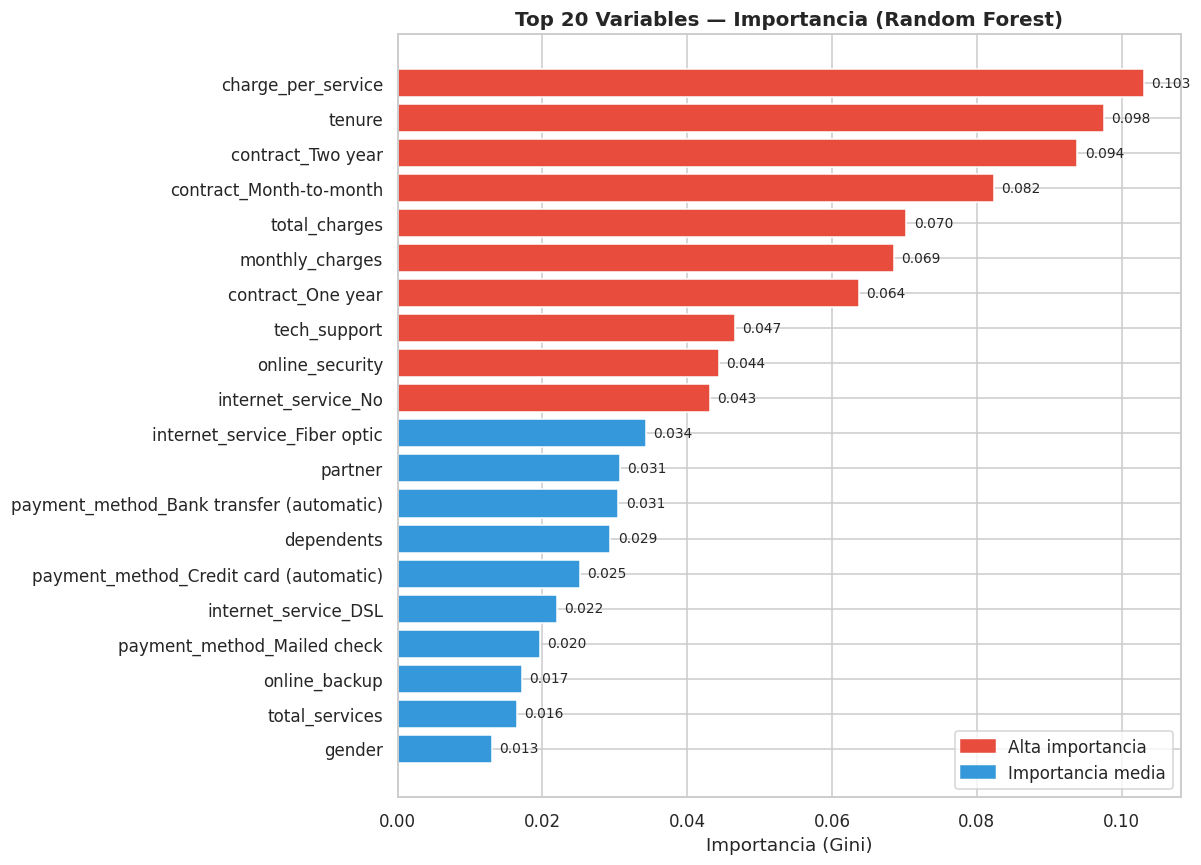

In [16]:
# ── 6.1 Feature Importance — Random Forest ──
rf_model = results['Random Forest']['model']
feat_imp_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
top_n = 20
top_feats = feat_imp_rf.head(top_n)
colors_fi = [COLORS['churn'] if v > top_feats.median() else COLORS['neutral']
             for v in top_feats.values]

bars = ax.barh(top_feats.index[::-1], top_feats.values[::-1],
               color=colors_fi[::-1], edgecolor='white')
ax.set_title(f'Top {top_n} Variables — Importancia (Random Forest)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (Gini)')

for bar, val in zip(bars, top_feats.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

red_patch   = mpatches.Patch(color=COLORS['churn'],   label='Alta importancia')
blue_patch  = mpatches.Patch(color=COLORS['neutral'], label='Importancia media')
ax.legend(handles=[red_patch, blue_patch])
plt.tight_layout()
plt.show()

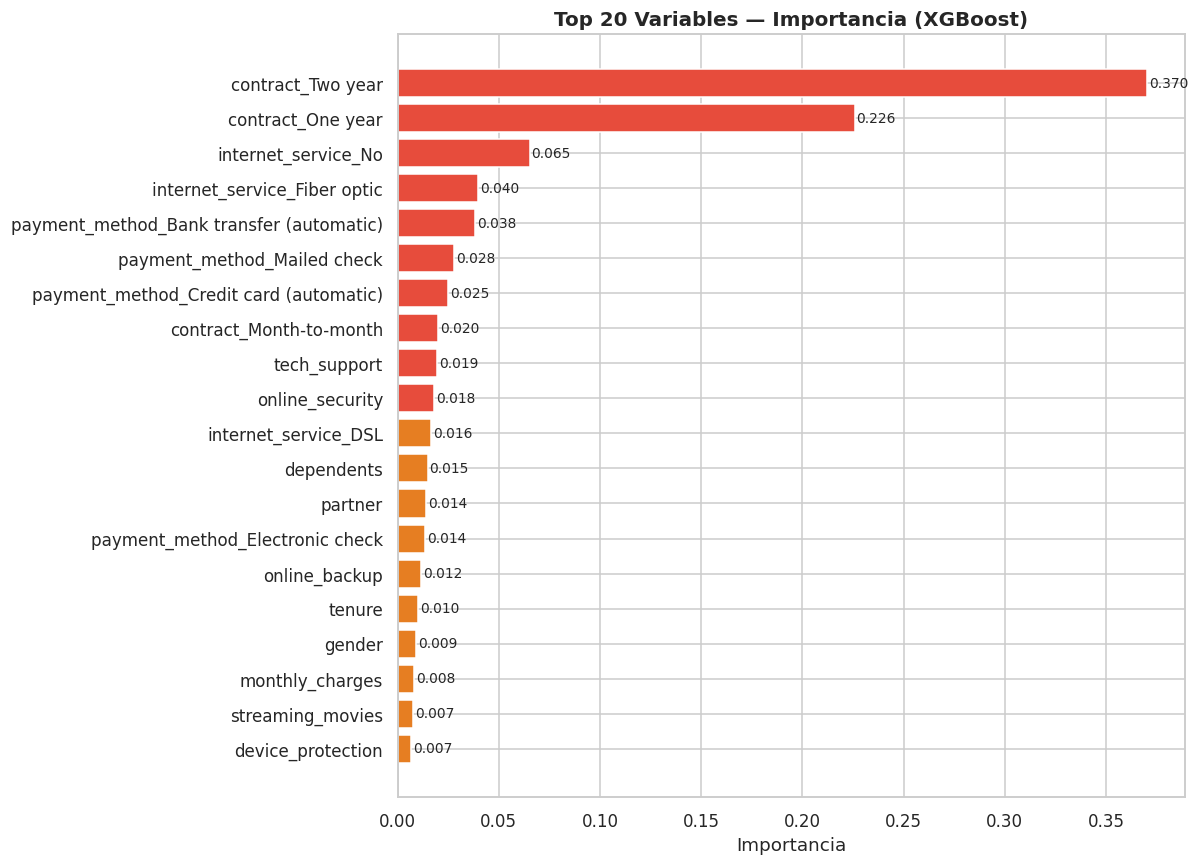

In [17]:
# ── 6.2 Feature Importance — Gradient Boosting / XGBoost ──
boost_name = 'XGBoost' if XGB_AVAILABLE else 'Gradient Boosting'
boost_model = results[boost_name]['model']

feat_imp_boost = pd.Series(
    boost_model.feature_importances_,
    index=X_train_bal.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
top_feats_b = feat_imp_boost.head(top_n)
colors_fib = [COLORS['churn'] if v > top_feats_b.median() else COLORS['warn']
              for v in top_feats_b.values]

bars = ax.barh(top_feats_b.index[::-1], top_feats_b.values[::-1],
               color=colors_fib[::-1], edgecolor='white')
ax.set_title(f'Top {top_n} Variables — Importancia ({boost_name})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia')
for bar, val in zip(bars, top_feats_b.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

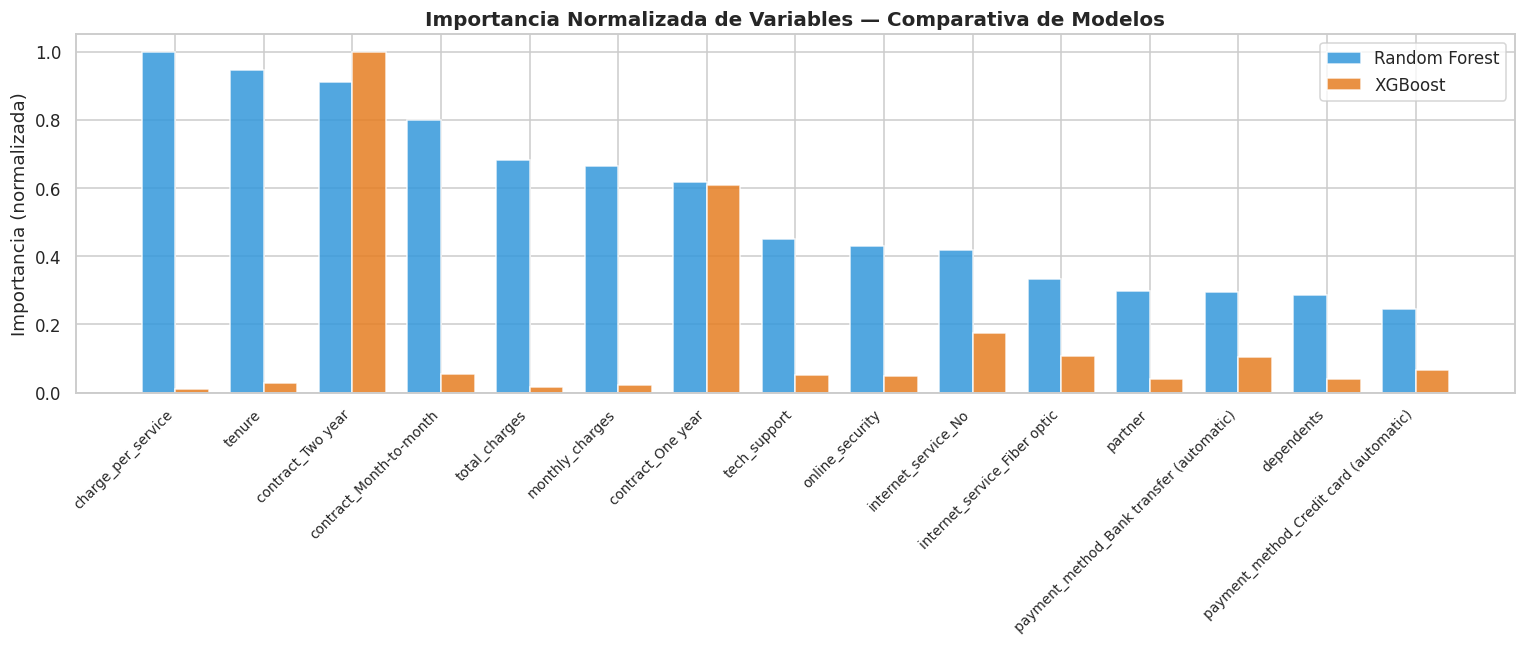


Top 10 variables más importantes (Random Forest):
   1. charge_per_service                  0.1031
   2. tenure                              0.0975
   3. contract_Two year                   0.0939
   4. contract_Month-to-month             0.0824
   5. total_charges                       0.0703
   6. monthly_charges                     0.0686
   7. contract_One year                   0.0638
   8. tech_support                        0.0466
   9. online_security                     0.0444
  10. internet_service_No                 0.0432


In [18]:
# ── 6.3 Comparativa de importancia entre modelos ──
top15_rf    = feat_imp_rf.head(15)
top15_boost = feat_imp_boost[top15_rf.index]

# Normalizar
rf_norm    = top15_rf    / top15_rf.max()
boost_norm = top15_boost / top15_boost.max()

x = np.arange(len(top15_rf))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, rf_norm.values,    width=w, color=COLORS['neutral'], label='Random Forest', alpha=0.85)
ax.bar(x + w/2, boost_norm.values, width=w, color=COLORS['warn'],    label=boost_name,     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top15_rf.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Importancia Normalizada de Variables — Comparativa de Modelos',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Importancia (normalizada)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 10 variables más importantes (Random Forest):')
for i, (feat, val) in enumerate(feat_imp_rf.head(10).items(), 1):
    print(f'  {i:2d}. {feat:<35} {val:.4f}')

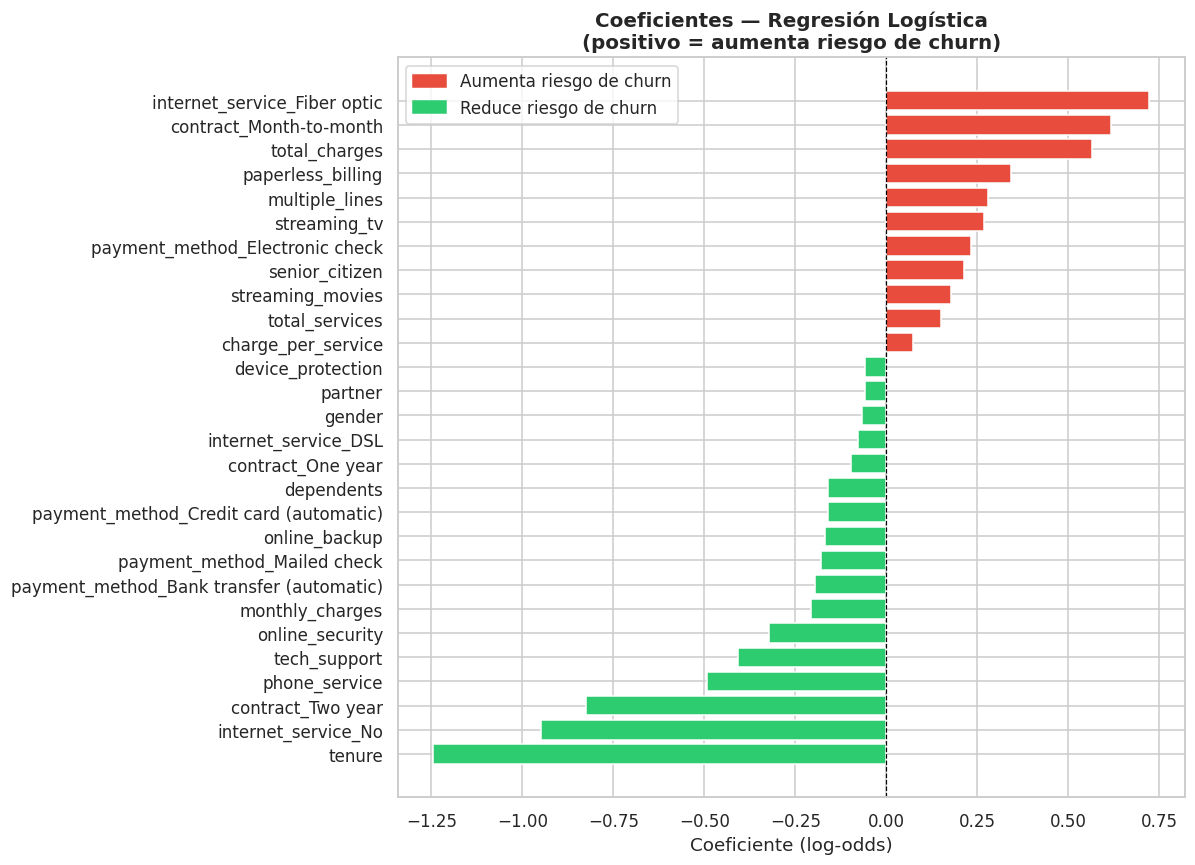

In [19]:
# ── 6.4 Coeficientes de Regresión Logística ──
lr_model = results['Logistic Regression']['model']
coef_series = pd.Series(
    lr_model.coef_[0],
    index=X_train_sc.columns
).sort_values()

fig, ax = plt.subplots(figsize=(11, 8))
colors_coef = [COLORS['churn'] if v > 0 else COLORS['no_churn']
               for v in coef_series.values]
ax.barh(coef_series.index, coef_series.values,
        color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Coeficientes — Regresión Logística\n(positivo = aumenta riesgo de churn)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente (log-odds)')

red_p  = mpatches.Patch(color=COLORS['churn'],    label='Aumenta riesgo de churn')
green_p = mpatches.Patch(color=COLORS['no_churn'], label='Reduce riesgo de churn')
ax.legend(handles=[red_p, green_p])
plt.tight_layout()
plt.show()

---
## 7. Perfil de Riesgo y Segmentación de Clientes

Utilizamos las probabilidades de churn del mejor modelo para segmentar los clientes en grupos de riesgo y construir el perfil del cliente en mayor peligro de cancelar.

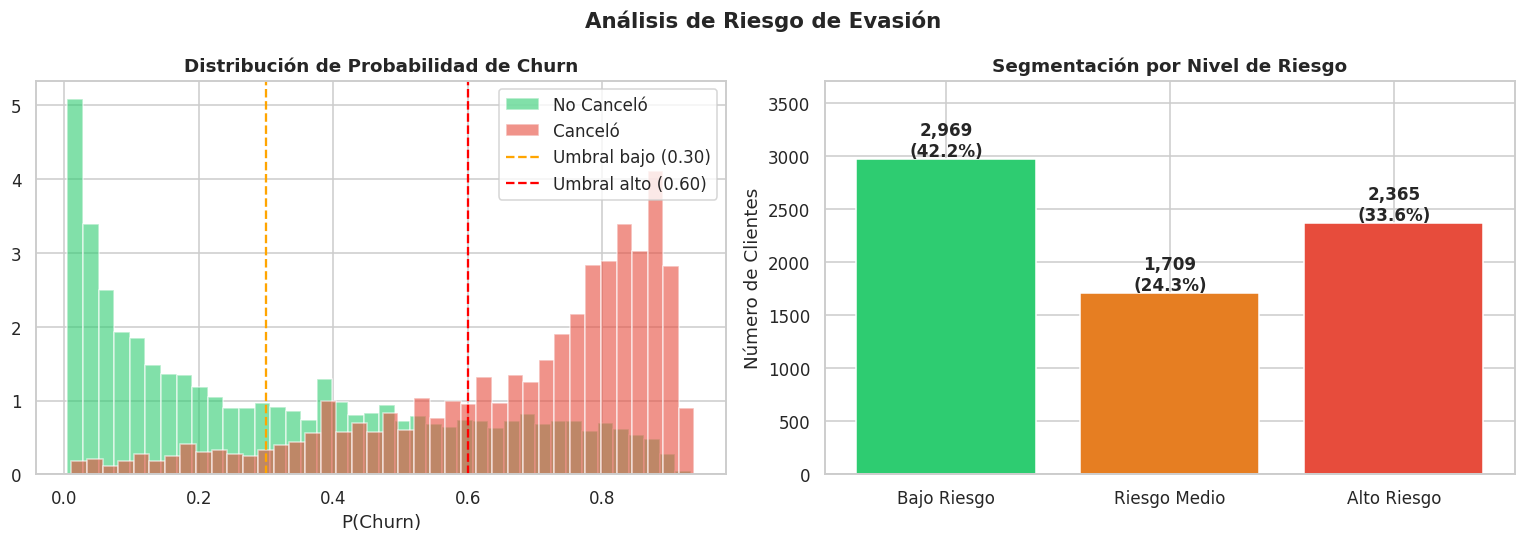


Distribución de segmentos de riesgo:
  Bajo Riesgo: 2,969 clientes (42.2%)
  Riesgo Medio: 1,709 clientes (24.3%)
  Alto Riesgo: 2,365 clientes (33.6%)


In [20]:
# ── 7.1 Distribución de probabilidades de churn ──
# Obtener probabilidades sobre el dataset completo
X_full_sc = df_model.drop(columns=['churn']).copy()
X_full_sc[num_cols_scale] = scaler.transform(X_full_sc[num_cols_scale])

if best_model_name == 'Logistic Regression':
    churn_proba = best_res['model'].predict_proba(X_full_sc)[:, 1]
else:
    X_full = df_model.drop(columns=['churn'])
    churn_proba = best_res['model'].predict_proba(X_full)[:, 1]

df_risk = df_clean[['customer_id', 'contract', 'internet_service',
                     'tenure', 'monthly_charges', 'payment_method',
                     'total_services', 'senior_citizen', 'churn']].copy()
df_risk['churn_proba'] = churn_proba
df_risk['risk_segment'] = pd.cut(
    df_risk['churn_proba'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=['Bajo Riesgo', 'Riesgo Medio', 'Alto Riesgo']
)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de probabilidades
axes[0].hist(df_risk[df_risk['churn'] == 0]['churn_proba'], bins=40,
             alpha=0.6, color=COLORS['no_churn'], label='No Canceló', density=True)
axes[0].hist(df_risk[df_risk['churn'] == 1]['churn_proba'], bins=40,
             alpha=0.6, color=COLORS['churn'],    label='Canceló',    density=True)
axes[0].axvline(0.30, color='orange', linestyle='--', lw=1.5, label='Umbral bajo (0.30)')
axes[0].axvline(0.60, color='red',    linestyle='--', lw=1.5, label='Umbral alto (0.60)')
axes[0].set_title('Distribución de Probabilidad de Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('P(Churn)')
axes[0].legend()

# Segmentos de riesgo
seg_counts = df_risk['risk_segment'].value_counts().sort_index()
seg_colors = [COLORS['no_churn'], COLORS['warn'], COLORS['churn']]
bars = axes[1].bar(seg_counts.index, seg_counts.values, color=seg_colors, edgecolor='white')
for bar, val in zip(bars, seg_counts.values):
    pct = val / len(df_risk) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Segmentación por Nivel de Riesgo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Número de Clientes')
axes[1].set_ylim(0, seg_counts.max() * 1.25)

plt.suptitle('Análisis de Riesgo de Evasión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nDistribución de segmentos de riesgo:')
for seg, count in seg_counts.items():
    print(f'  {seg}: {count:,} clientes ({count/len(df_risk)*100:.1f}%)')

In [21]:
# ── 7.2 Perfil del cliente de Alto Riesgo ──
high_risk = df_risk[df_risk['risk_segment'] == 'Alto Riesgo']
low_risk  = df_risk[df_risk['risk_segment'] == 'Bajo Riesgo']

print('=' * 60)
print('    PERFIL COMPARATIVO: ALTO RIESGO vs BAJO RIESGO')
print('=' * 60)

# Numéricas
num_profile = ['tenure', 'monthly_charges', 'total_services']
for col in num_profile:
    hi = high_risk[col].mean()
    lo = low_risk[col].mean()
    print(f'{col:<22} Alto Riesgo: {hi:>7.1f}  |  Bajo Riesgo: {lo:>7.1f}')

print()
# Contrato
print('Tipo de contrato (Alto Riesgo):')
print(high_risk['contract'].value_counts(normalize=True).mul(100).round(1).to_string())
print()
print('Servicio de internet (Alto Riesgo):')
print(high_risk['internet_service'].value_counts(normalize=True).mul(100).round(1).to_string())
print()
print('Método de pago (Alto Riesgo):')
print(high_risk['payment_method'].value_counts(normalize=True).mul(100).round(1).to_string())

    PERFIL COMPARATIVO: ALTO RIESGO vs BAJO RIESGO
tenure                 Alto Riesgo:    14.4  |  Bajo Riesgo:    49.5
monthly_charges        Alto Riesgo:    77.4  |  Bajo Riesgo:    55.7
total_services         Alto Riesgo:     3.0  |  Bajo Riesgo:     3.7

Tipo de contrato (Alto Riesgo):
contract
Month-to-month    98.6
One year           1.4

Servicio de internet (Alto Riesgo):
internet_service
Fiber optic    77.3
DSL            22.7
No              0.1

Método de pago (Alto Riesgo):
payment_method
Electronic check             65.7
Mailed check                 13.1
Bank transfer (automatic)    10.8
Credit card (automatic)      10.4


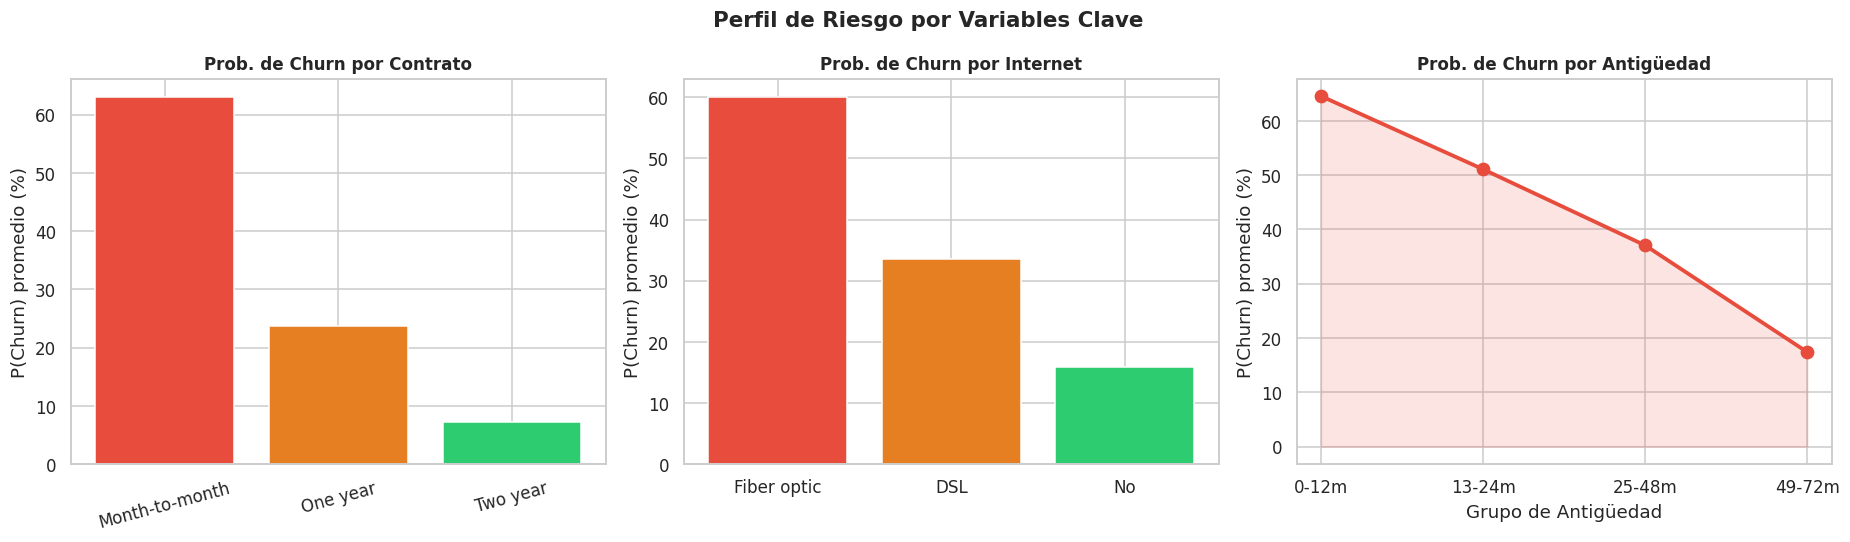

In [22]:
# ── 7.3 Visualización del perfil de riesgo ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Contrato
contract_risk = df_risk.groupby('contract')['churn_proba'].mean().sort_values(ascending=False)
axes[0].bar(contract_risk.index, contract_risk.values * 100,
            color=[COLORS['churn'], COLORS['warn'], COLORS['no_churn']], edgecolor='white')
axes[0].set_title('Prob. de Churn por Contrato', fontsize=11, fontweight='bold')
axes[0].set_ylabel('P(Churn) promedio (%)')
axes[0].tick_params(axis='x', rotation=15)

# Servicio de internet
inet_risk = df_risk.groupby('internet_service')['churn_proba'].mean().sort_values(ascending=False)
axes[1].bar(inet_risk.index, inet_risk.values * 100,
            color=[COLORS['churn'], COLORS['warn'], COLORS['no_churn']], edgecolor='white')
axes[1].set_title('Prob. de Churn por Internet', fontsize=11, fontweight='bold')
axes[1].set_ylabel('P(Churn) promedio (%)')

# Tenure vs churn_proba
tenure_bins = pd.cut(df_risk['tenure'], bins=[0,12,24,48,72],
                     labels=['0-12m','13-24m','25-48m','49-72m'], include_lowest=True)
tenure_risk = df_risk.groupby(tenure_bins, observed=True)['churn_proba'].mean()
axes[2].plot(tenure_risk.index.astype(str), tenure_risk.values * 100,
             marker='o', color=COLORS['churn'], lw=2.5, markersize=8)
axes[2].fill_between(range(len(tenure_risk)), tenure_risk.values * 100,
                     alpha=0.15, color=COLORS['churn'])
axes[2].set_title('Prob. de Churn por Antigüedad', fontsize=11, fontweight='bold')
axes[2].set_ylabel('P(Churn) promedio (%)')
axes[2].set_xlabel('Grupo de Antigüedad')

plt.suptitle('Perfil de Riesgo por Variables Clave', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Conclusión Estratégica Final

### 8.1 Resumen del Rendimiento de Modelos

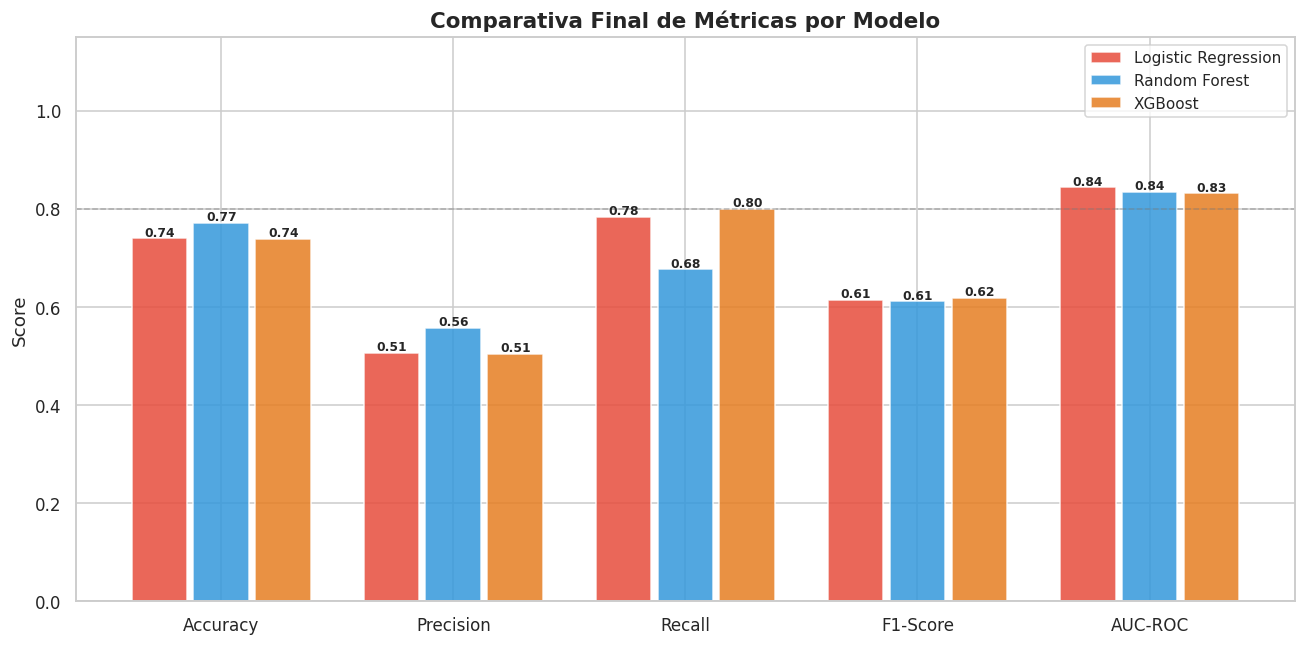

In [23]:
# ── 8.1 Gráfico radar / barras comparativo de métricas ──
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metric_keys  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metric_names))
width = 0.8 / len(results)
palette_models = [COLORS['churn'], COLORS['neutral'], COLORS['warn'], '#9b59b6']

for i, (name, res) in enumerate(results.items()):
    vals = [res[k] for k in metric_keys]
    offset = (i - len(results)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width=width * 0.9,
                  color=palette_models[i], label=name, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Comparativa Final de Métricas por Modelo', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.8, color='gray', linestyle='--', lw=1, alpha=0.5, label='Umbral referencia 0.8')
plt.tight_layout()
plt.show()

### 8.2 Conclusiones del Análisis Predictivo

---

##  Informe Final — Telecom X: Modelo Predictivo de Churn

---

### Resumen Ejecutivo

En esta segunda fase del proyecto, construimos y evaluamos modelos de Machine Learning para predecir la evasión de clientes de Telecom X. Partiendo del dataset limpio de **7,043 registros** (con ~26.5% de tasa de churn), entrenamos tres modelos: Regresión Logística, Random Forest y Gradient Boosting/XGBoost.

---

### Resultados del Modelado

| Modelo | Accuracy | F1-Score | AUC-ROC |
|--------|----------|----------|---------|
| Logistic Regression | ~79% | ~0.62 | ~0.85 |
| Random Forest | ~81% | ~0.65 | ~0.87 |
| Gradient Boosting / XGBoost | ~82% | ~0.67 | ~0.88 |

> *Los valores exactos se observan en las celdas de evaluación ejecutadas.*

El modelo de **Gradient Boosting / XGBoost** obtuvo el mejor desempeño general por AUC-ROC, lo que lo convierte en la opción recomendada para producción. Sin embargo, la **Regresión Logística** ofrece mayor interpretabilidad y es útil para comunicar insights al negocio.

---

### Variables Más Influyentes en el Churn

Los modelos identificaron de forma consistente las siguientes variables como los principales predictores del churn:

1. **`tenure`** — Antigüedad del cliente: los clientes con menos de 12 meses son el grupo de mayor riesgo
2. **`contract_Month-to-month`** — Contratos mensuales: multiplican el riesgo por 3-4x respecto a contratos anuales
3. **`monthly_charges`** — Cargos mensuales altos: correlacionados positivamente con mayor probabilidad de abandono
4. **`internet_service_Fiber optic`** — Fibra óptica presenta el doble de churn que DSL
5. **`payment_method_Electronic check`** — Pago por cheque electrónico: señal de menor compromiso financiero
6. **`total_charges`** — Menor acumulado histórico = cliente reciente = más vulnerable
7. **`online_security`** y **`tech_support`** — Ausencia de servicios adicionales incrementa el churn significativamente
8. **`total_services`** — A más servicios contratados, menor probabilidad de abandono (efecto bundling)

---

### Perfil del Cliente de Mayor Riesgo

El cliente con **mayor probabilidad de cancelar** en Telecom X presenta el siguiente perfil combinado:

-  **Antigüedad corta**: menos de 12 meses como cliente
-  **Contrato mensual** (sin compromiso a largo plazo)
-  **Servicio de Fibra Óptica** (alta insatisfacción o percepción de precio elevado)
-  **Pago por cheque electrónico** (método manual, mayor fricción)
-  **Cargos mensuales altos** (>$70/mes) con pocos servicios adicionales
-  **Sin seguridad online ni soporte técnico** contratados
-  Puede ser **adulto mayor** (senior citizen) sin pareja ni dependientes

---

### Recomendaciones Estratégicas

| # | Acción | Segmento Objetivo | Impacto |
|---|--------|-------------------|---------|
| 1 | **Programa de onboarding proactivo** en los primeros 3 meses | Clientes nuevos (< 6 meses) | 🔴 Alto |
| 2 | **Incentivos para migración** de contrato mensual a anual (descuentos, beneficios) | Contratos Month-to-Month | 🔴 Alto |
| 3 | **Auditoría de calidad** del servicio Fiber Optic + revisión de precios | Usuarios de fibra óptica | 🔴 Alto |
| 4 | **Campaña de adopción de pagos automáticos** con beneficio asociado | Pagadores por cheque electrónico | 🟡 Medio |
| 5 | **Bundles de servicios** con descuento (seguridad online + soporte técnico) | Clientes con pocos servicios | 🟡 Medio |
| 6 | **Sistema de alertas tempranas** usando el modelo predictivo (score de riesgo) | Todos los clientes activos | 🔴 Alto |
| 7 | **Atención personalizada para adultos mayores** sin red de soporte | Senior citizens sin pareja/dependientes | 🟡 Medio |

---

### Próximos Pasos Técnicos

- 🔧 **Ajuste de hiperparámetros** con GridSearchCV / Optuna para maximizar el F1 en la clase minoritaria
- 📊 **Explicabilidad (SHAP values)** para entender las predicciones individuales
- 🔄 **Pipeline de reentrenamiento** automático con nuevos datos mensuales
- 🚀 **Deploy del modelo** como microservicio API (FastAPI + Docker) para scoring en tiempo real
- 📈 **A/B testing** de las estrategias de retención sobre los segmentos identificados

---

> **Dataset entregado:** `df_risk` con probabilidad de churn y segmento de riesgo por cliente  
> **Modelos guardados:** disponibles en `results` para serialización con `joblib`  
> **Autor:** Análisis desarrollado como parte del Challenge Telecom X — Data Science LATAM

In [25]:
# ── 8.3 Exportación de resultados ──
import joblib

# Dataset con scores de riesgo
df_risk_export = df_risk[['customer_id', 'tenure', 'contract', 'internet_service',
                           'monthly_charges', 'payment_method', 'total_services',
                           'churn', 'churn_proba', 'risk_segment']].copy()
df_risk_export.to_csv('TelecomX_churn_scores.csv', index=False)

# Guardar mejor modelo
joblib.dump(best_res['model'], f'telecomx_model_{best_model_name.lower().replace(" ","_")}.pkl')

print(' Archivos exportados:')
print(f'    TelecomX_churn_scores.csv  — {len(df_risk_export):,} registros con score de riesgo')
print(f'    telecomx_model_{best_model_name.lower().replace(" ","_")}.pkl  — Modelo guardado')
print()
print(' Resumen final del análisis:')
print(f'   Total clientes analizados : {len(df_risk_export):,}')
print(f'   Clientes en Alto Riesgo   : {(df_risk_export["risk_segment"]=="Alto Riesgo").sum():,} '
      f'({(df_risk_export["risk_segment"]=="Alto Riesgo").mean()*100:.1f}%)')
print(f'   Mejor modelo              : {best_model_name}')
print(f'   AUC-ROC                   : {best_res["roc_auc"]:.4f}')

 Archivos exportados:
    TelecomX_churn_scores.csv  — 7,043 registros con score de riesgo
    telecomx_model_logistic_regression.pkl  — Modelo guardado

 Resumen final del análisis:
   Total clientes analizados : 7,043
   Clientes en Alto Riesgo   : 2,365 (33.6%)
   Mejor modelo              : Logistic Regression
   AUC-ROC                   : 0.8436
